# Exploratory Data Analysis

## Objective

This notebook examines the analytical cohort before modeling. It focuses on:

- Target distribution and class imbalance
- Missing-value patterns
- Numerical feature distributions
- Categorical feature distributions
- Associations between candidate predictors and diabetes-range HbA1c
- Unweighted and survey-weighted outcome prevalence

This analysis is descriptive and does not establish causal relationships.

In [1]:
# Import necessary libraries
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Set the graphical settings accordingly
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

In [3]:
# Load the saved analysis dataset 
DATA_PATH = Path("../artifacts/analysis_cohort.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (4698, 14)


,SEQN,RIDAGEYR,RIAGENDR,RIDRETH3,DMDEDUC2,INDFMPIR,BMXBMI,BMXWAIST,LBXGH,WTPH2YR,SDMVSTRA,SDMVPSU,WTMEC2YR,a1c_diabetes_range
0,130378.000,43.000,1.000,6.000,5.000,5.000,27.000,98.300,5.600,56042.129,173.000,2.000,54374.464,0
1,130379.000,66.000,1.000,3.000,5.000,5.000,33.500,114.700,5.600,37435.706,173.000,2.000,34084.722,0
2,130386.000,34.000,1.000,1.000,4.000,1.330,30.200,106.100,5.100,44526.214,179.000,1.000,39988.453,0
3,130387.000,68.000,2.000,3.000,5.000,1.320,42.600,122.000,5.900,22746.296,181.000,1.000,20776.255,0
4,130388.000,27.000,2.000,4.000,4.000,0.810,43.700,118.500,4.900,32864.291,187.000,1.000,30329.536,0


a1c_diabetes_range
0    4582
1     116
Name: count, dtype: int64
a1c_diabetes_range
0   97.530
1    2.470
Name: proportion, dtype: float64


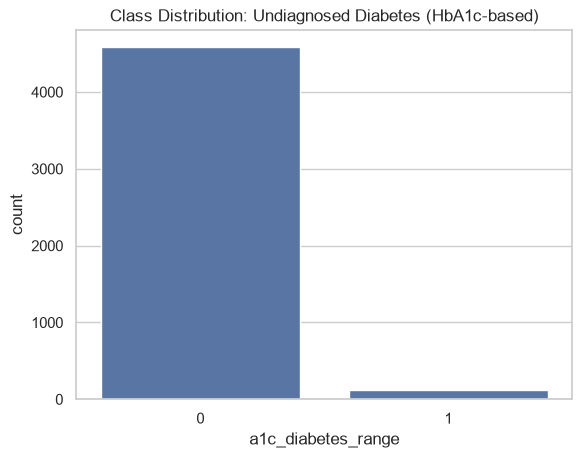

In [4]:
# Analyze the target variable distribution
counts = df["a1c_diabetes_range"].value_counts()
pct = df["a1c_diabetes_range"].value_counts(normalize=True) * 100
print(counts)
print(pct.round(2))

sns.countplot(data=df, x="a1c_diabetes_range")
plt.title("Class Distribution: Undiagnosed Diabetes (HbA1c-based)")
plt.show()


The target variable is heavily imbalanced: approximately 2.5% of the cohort  (unweighted) has diabetes-range HbA1c with no prior diagnosis, consistent with  the low population prevalence of undiagnosed diabetes. This imbalance has two  implications for modeling:

1. Standard accuracy is not a meaningful evaluation metric, a model that always 
   predicts "0" would achieve ~97.5% accuracy while being clinically useless.
2. Class weighting or resampling will be needed during model training, and 
   evaluation should prioritize recall, precision-recall AUC, and calibration.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4698 entries, 0 to 4697
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   SEQN                4698 non-null   float64
 1   RIDAGEYR            4698 non-null   float64
 2   RIAGENDR            4698 non-null   float64
 3   RIDRETH3            4698 non-null   float64
 4   DMDEDUC2            4696 non-null   float64
 5   INDFMPIR            4097 non-null   float64
 6   BMXBMI              4641 non-null   float64
 7   BMXWAIST            4512 non-null   float64
 8   LBXGH               4698 non-null   float64
 9   WTPH2YR             4698 non-null   float64
 10  SDMVSTRA            4698 non-null   float64
 11  SDMVPSU             4698 non-null   float64
 12  WTMEC2YR            4698 non-null   float64
 13  a1c_diabetes_range  4698 non-null   int64  
dtypes: float64(13), int64(1)
memory usage: 514.0 KB


In [6]:
# Missing Values
df.isnull().sum().sort_values(ascending=False)

INDFMPIR              601
BMXWAIST              186
BMXBMI                 57
DMDEDUC2                2
SEQN                    0
RIDAGEYR                0
RIAGENDR                0
RIDRETH3                0
LBXGH                   0
WTPH2YR                 0
SDMVSTRA                0
SDMVPSU                 0
WTMEC2YR                0
a1c_diabetes_range      0
dtype: int64

`INDFMPIR` has 601 missing data, this may indicate that there is a possibility that people didn't prefer to share their incomes because of it's low or it may also indicate that they are unemployed and have no income.

In [7]:
df["INDFMPIR_missing"] = df["INDFMPIR"].isna()
df.groupby("INDFMPIR_missing")["a1c_diabetes_range"].mean()

INDFMPIR_missing
False   0.025
True    0.023
Name: a1c_diabetes_range, dtype: float64

We tested whether missingness in `INDFMPIR` is related to the outcome by 
comparing outcome rates between missing and non-missing groups:
- Non-missing: 2.5% undiagnosed
- Missing: 2.3% undiagnosed

The near-identical rates suggest missingness in `INDFMPIR` is not strongly 
associated with the outcome (i.e., likely missing at random rather than 
missing not at random), supporting a straightforward imputation approach 
(e.g., median imputation) in the preprocessing step.

In [8]:
df["BMXWAIST_missing"] = df["BMXWAIST"].isna()
df.groupby("BMXWAIST_missing")["a1c_diabetes_range"].mean()

BMXWAIST_missing
False   0.025
True    0.022
Name: a1c_diabetes_range, dtype: float64

In [9]:
df["BMXBMI_missing"] = df["BMXBMI"].isna()
df.groupby("BMXBMI_missing")["a1c_diabetes_range"].mean()

BMXBMI_missing
False   0.025
True    0.018
Name: a1c_diabetes_range, dtype: float64

### Missing Value Pattern Check

We tested whether missingness in `INDFMPIR`, `BMXBMI`, and `BMXWAIST` is 
related to the outcome by comparing outcome rates between missing and 
non-missing groups:

| Feature    | Non-missing | Missing |
|------------|-------------|---------|
| INDFMPIR   | 2.5%        | 2.3%    |
| BMXBMI     | 2.5%        | 1.8%    |
| BMXWAIST   | 2.5%        | 2.2%    |

Outcome rates are similar across missing and non-missing groups for all three 
variables, suggesting missingness is unrelated to the outcome (consistent with 
missing-at-random rather than missing-not-at-random). This supports using 
straightforward imputation (e.g., median imputation) for these variables in 
the preprocessing step, without needing a separate missingness indicator to 
avoid information leakage.

In [10]:
# Differentiate the variable types
numerical_features = [
    "RIDAGEYR", # Age in years
    "INDFMPIR", # Income-to-poverty ratio
    "BMXBMI",   # Body mass index
    "BMXWAIST"  # Waist circumference in cm
]

categorical_features = [
    "RIAGENDR", # 1: Male, 0: Female (Nominal)
    "RIDRETH3", # Race ethnicity category (Nominal)
                # 1: Mexican American
                # 2: Other Hispanic
                # 3: Non-Hispanic White
                # 4: Non-Hispanic Black
                # 6: Non-Hispanic Asian
                # 7: Other/Multi-racial
    
    "DMDEDUC2" # Education level (Ordinal)
               # 1: Less than 9th grade
               # 2: 9–11th grade
               # 3: High school/GED
               # 4: Some college/AA
               # 5: College graduate or above 
]
non_model_columns = [
    "SEQN",
    "LBXGH",
    "WTPH2YR",
    "SDMVSTRA",
    "SDMVPSU"
]

target = "a1c_diabetes_range"
weight = "WTPH2YR"

In [11]:
# Numerical Summary
df[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
RIDAGEYR,4698.000,52.256,17.276,20.000,37.000,54.000,67.000,80.000
INDFMPIR,4097.000,3.040,1.653,0.000,1.530,3.040,5.000,5.000
BMXBMI,4641.000,29.171,6.988,11.100,24.300,27.800,32.600,74.800
BMXWAIST,4512.000,99.167,16.128,60.000,87.600,97.800,109.000,187.000


In [12]:
df[numerical_features].skew().sort_values(
    ascending=False
)

BMXBMI      1.312
BMXWAIST    0.637
RIDAGEYR   -0.141
INDFMPIR   -0.149
dtype: float64

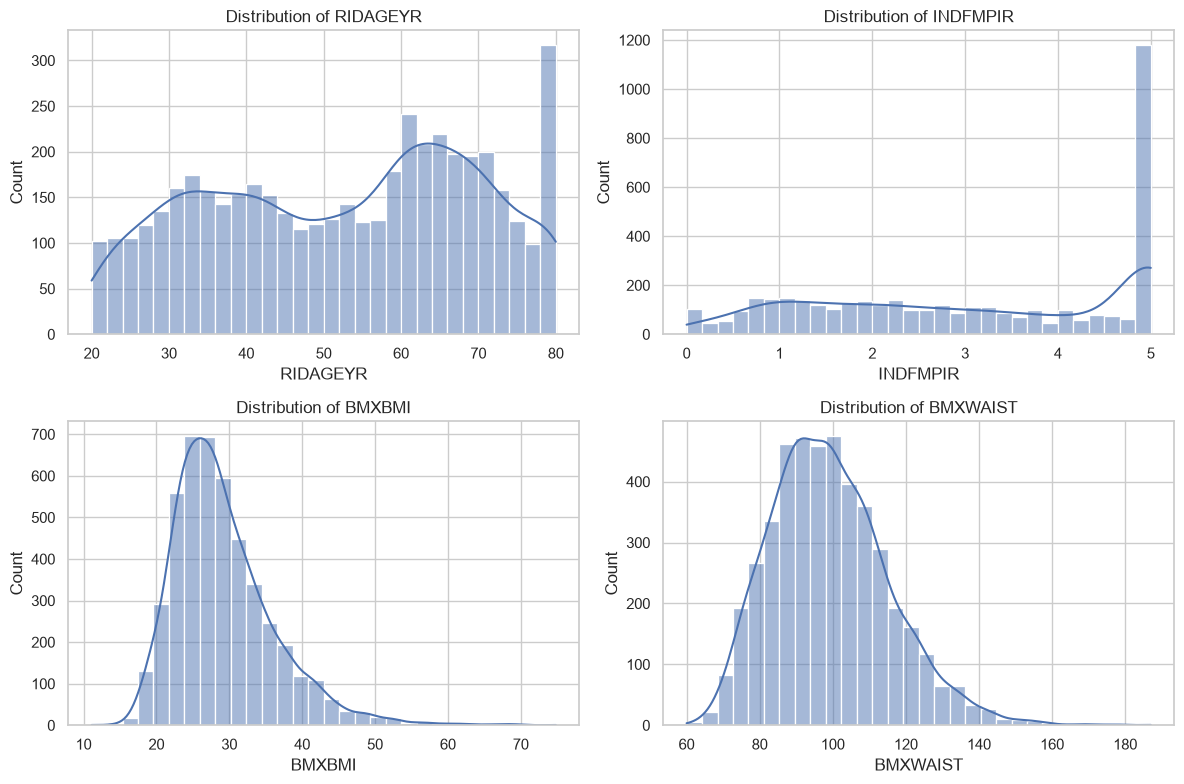

In [13]:
# Distributions of Numerical Features

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8)
)

axes = axes.flatten()

for feature, ax in zip(
    numerical_features,
    axes
):
    sns.histplot(
        data=df,
        x=feature,
        bins=30,
        kde=True,
        ax=ax
    )

    ax.set_title(
        f"Distribution of {feature}"
    )

plt.tight_layout()
plt.show()

**Interpretation of Numerical Feature Distributions**

- **Age (`RIDAGEYR`)** is not normally distributed. The concentration at 80 occurs because NHANES top-codes participants aged 80 years and older as 80.
- **Income-to-poverty ratio (`INDFMPIR`)** contains a large concentration at 5 because NHANES top-codes ratios of 5 or higher as 5. Therefore, these observations should not be treated as outliers.
- **BMI (`BMXBMI`)** is right-skewed, with a relatively small number of participants having very high BMI values.
- **Waist circumference (`BMXWAIST`)** is also right-skewed, although its distribution appears smoother than the BMI distribution.

In [14]:
df.groupby("a1c_diabetes_range")[numerical_features].agg(
    ["count", "mean", "median", "std"]
).round(2).T

a1c_diabetes_range        0       1
RIDAGEYR count     4582.000 116.000
         mean        52.070  59.720
         median      54.000  61.000
         std         17.300  14.380
INDFMPIR count     3995.000 102.000
         mean         3.050   2.470
         median       3.040   2.120
         std          1.660   1.440
BMXBMI   count     4526.000 115.000
         mean        29.050  33.970
         median      27.700  32.500
         std          6.940   7.190
BMXWAIST count     4400.000 112.000
         mean        98.830 112.420
         median      97.400 111.750
         std         16.020  14.780

Participants in the HbA1c diabetes-range group tended to be older and had higher BMI and waist circumference, while their median income-to-poverty ratio was lower. Mann–Whitney U tests were subsequently used to evaluate whether the observed differences in the continuous variables were statistically significant.

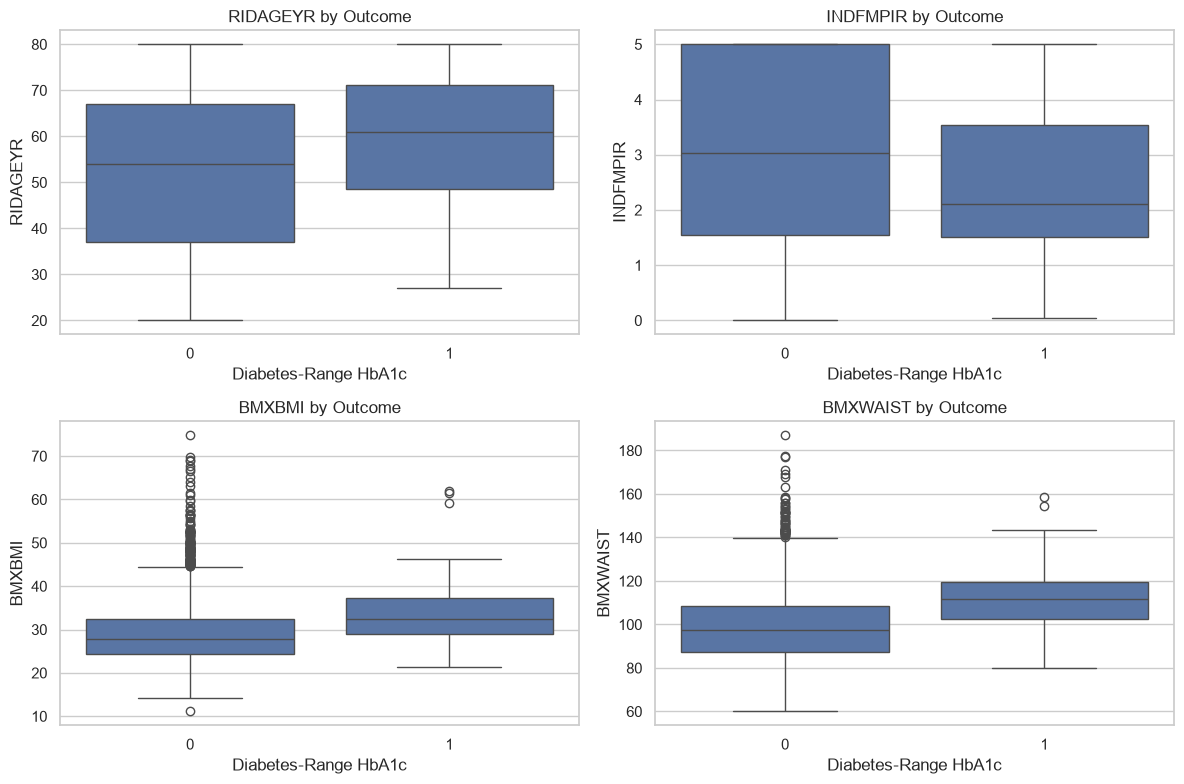

In [15]:
# Numerical Feature Boxplot 
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8)
)

axes = axes.flatten()

for feature, ax in zip(
    numerical_features,
    axes
):
    sns.boxplot(
        data=df,
        x="a1c_diabetes_range",
        y=feature,
        ax=ax
    )

    ax.set_title(
        f"{feature} by Outcome"
    )

    ax.set_xlabel(
        "Diabetes-Range HbA1c"
    )

plt.tight_layout()
plt.show()

In [16]:
from scipy.stats import mannwhitneyu
import pandas as pd

target = "a1c_diabetes_range"
continuous_features = ["RIDAGEYR", "BMXBMI", "INDFMPIR"]

results = []

for feature in continuous_features:
    group_0 = df.loc[df[target] == 0, feature].dropna()
    group_1 = df.loc[df[target] == 1, feature].dropna()

    u_stat, p_value = mannwhitneyu(
        group_0,
        group_1,
        alternative="two-sided",
        method="asymptotic"
    )

    results.append({
        "feature": feature,
        "non_diabetic_n": len(group_0),
        "diabetic_n": len(group_1),
        "non_diabetic_median": group_0.median(),
        "diabetic_median": group_1.median(),
        "non_diabetic_IQR": group_0.quantile(0.75) - group_0.quantile(0.25),
        "diabetic_IQR": group_1.quantile(0.75) - group_1.quantile(0.25),
        "U_statistic": u_stat,
        "p_value": p_value
    })

mw_results = pd.DataFrame(results)
mw_results

,feature,non_diabetic_n,diabetic_n,non_diabetic_median,diabetic_median,non_diabetic_IQR,diabetic_IQR,U_statistic,p_value
0,RIDAGEYR,4582,116,54.000,61.000,30.000,22.750,198738.500,0.000
1,BMXBMI,4526,115,27.700,32.500,8.100,8.200,147086.500,0.000
2,INDFMPIR,3995,102,3.040,2.115,3.460,2.033,245008.500,0.000


Mann–Whitney U tests showed that the distributions of age, BMI, and income-to-poverty ratio differed significantly between participants whose HbA1c levels were within the diabetes range and those whose levels were outside this range. Participants in the diabetes-range group tended to be older, have a higher BMI, and have a lower income-to-poverty ratio. Among the continuous variables examined, BMI showed the largest difference between the groups.

In [17]:
# Categorical Feature Analysis
for col in categorical_features:
    print(df[col].value_counts(normalize=True).round(3) * 100)

RIAGENDR
2.000   55.600
1.000   44.400
Name: proportion, dtype: float64
RIDRETH3
3.000   61.100
4.000   11.000
2.000   10.000
1.000    6.500
7.000    6.100
6.000    5.300
Name: proportion, dtype: float64
DMDEDUC2
5.000   39.100
4.000   30.500
3.000   20.100
2.000    6.500
1.000    3.800
Name: proportion, dtype: float64


In [18]:
def categorical_summary(df, col, target):
    summary = df.groupby(col)[target].agg(["count", "mean"]).round(3)
    summary.columns = ["n", "outcome_rate"]
    summary["pct_of_sample"] = (summary["n"] / summary["n"].sum() * 100).round(1)
    return summary.sort_values("outcome_rate", ascending=False)

for col in categorical_features:
    print(f"\n--- {col} ---")
    print(categorical_summary(df, col, "a1c_diabetes_range"))


--- RIAGENDR ---
             n  outcome_rate  pct_of_sample
RIAGENDR                                   
1.000     2084         0.027         44.400
2.000     2614         0.023         55.600

--- RIDRETH3 ---
             n  outcome_rate  pct_of_sample
RIDRETH3                                   
4.000      517         0.050         11.000
1.000      304         0.049          6.500
2.000      469         0.023         10.000
3.000     2872         0.020         61.100
6.000      251         0.020          5.300
7.000      285         0.007          6.100

--- DMDEDUC2 ---
             n  outcome_rate  pct_of_sample
DMDEDUC2                                   
2.000      307         0.062          6.500
1.000      179         0.061          3.800
3.000      944         0.024         20.100
4.000     1432         0.024         30.500
5.000     1834         0.016         39.100


In [19]:
# DMDEDUC2: 9 = "Don't Know" take it as missing value
df["DMDEDUC2"] = df["DMDEDUC2"].replace(9, np.nan)
print(df["DMDEDUC2"].value_counts(dropna=False))

DMDEDUC2
5.000    1834
4.000    1432
3.000     944
2.000     307
1.000     179
NaN         2
Name: count, dtype: int64



`DMDEDUC2` contains a code value of 9 ("Don't Know"), present for only 2 
respondents. This is not a valid education category and was recoded to missing 
(NaN) prior to statistical testing, since including it violated the chi-square 
test's minimum expected cell count assumption (expected count = 0.0).

In [20]:
from scipy.stats import chi2_contingency

for col in categorical_features:
    contingency = pd.crosstab(df[col], df["a1c_diabetes_range"])
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f"{col}: chi2={chi2:.2f}, p={p:.4f}, dof={dof}")

RIAGENDR: chi2=0.91, p=0.3399, dof=1
RIDRETH3: chi2=28.50, p=0.0000, dof=5
DMDEDUC2: chi2=33.73, p=0.0000, dof=4


For `RIAGENDR` (Gender), there is no visible relationship with the target variable. But, `RIEDRETH3` and `DMDEDUC2` has p-value less than 0.05 which clearly shows that there is some kind of relationship with the target variable.

In [21]:
# Apply Cramer's V to see if the relationships are strong or weak
n = len(df)

for col in categorical_features:
    contingency = pd.crosstab(
        df[col],
        df["a1c_diabetes_range"]
    )

    chi2, p, dof, expected = chi2_contingency(contingency)

    cramers_v = np.sqrt(
        chi2 / (contingency.to_numpy().sum() *
                (min(contingency.shape) - 1))
    )

    print(
        f"{col}: chi2={chi2:.2f}, "
        f"p={p:.3e}, "
        f"Cramer's V={cramers_v:.3f}, "
        f"minimum expected={expected.min():.2f}"
    )

RIAGENDR: chi2=0.91, p=3.399e-01, Cramer's V=0.014, minimum expected=51.46
RIDRETH3: chi2=28.50, p=2.903e-05, Cramer's V=0.078, minimum expected=6.20
DMDEDUC2: chi2=33.73, p=8.457e-07, Cramer's V=0.085, minimum expected=4.42


The chi-square test found no statistically significant evidence of an association between gender and HbA1c diabetes-range status (p = 0.340). Race/ethnicity and education level were significantly associated with the outcome (p < 0.001); however, their Cramér’s V values indicated that these associations were weak.

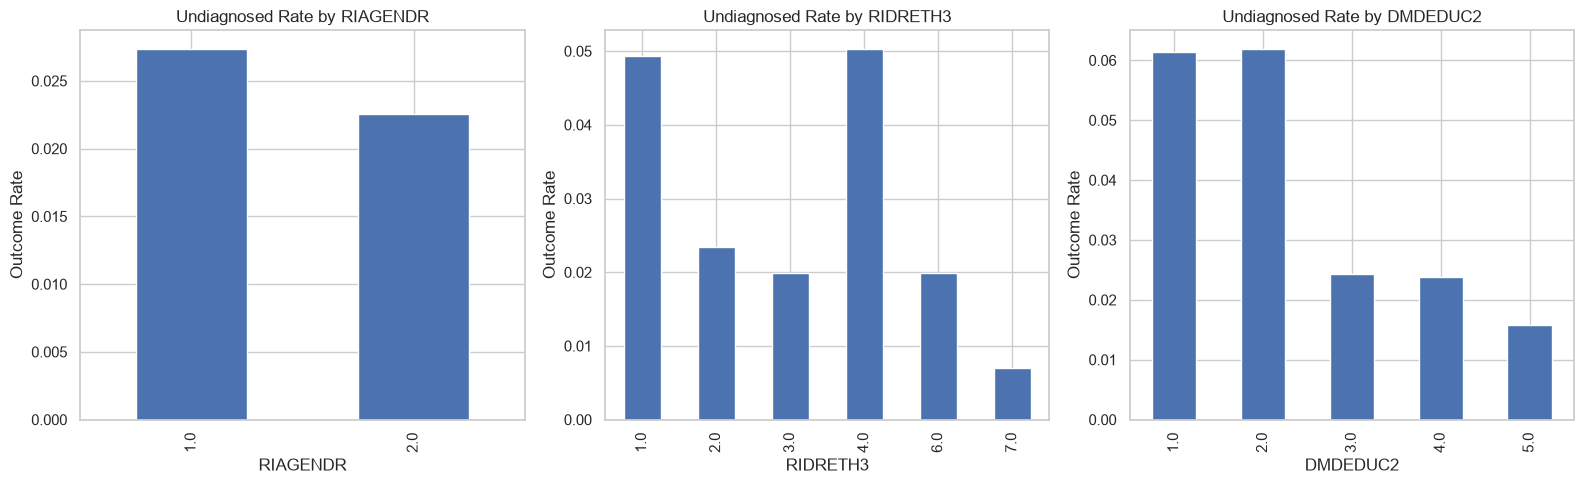

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for col, ax in zip(categorical_features, axes):
    rate = df.groupby(col)["a1c_diabetes_range"].mean()
    rate.plot(kind="bar", ax=ax)
    ax.set_title(f"Undiagnosed Rate by {col}")
    ax.set_ylabel("Outcome Rate")
plt.tight_layout()
plt.show()

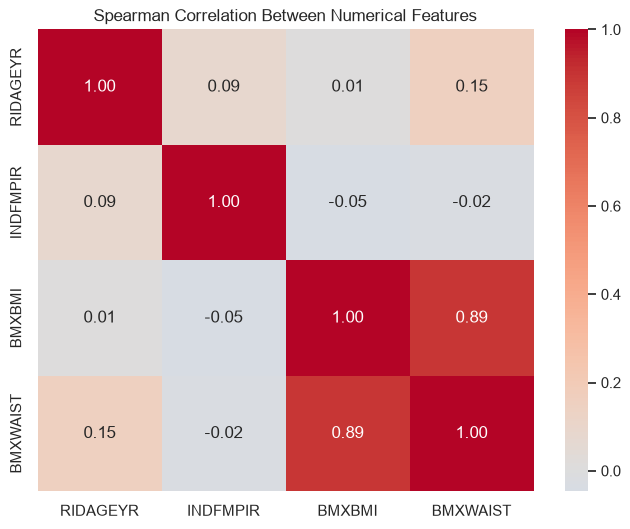

In [23]:
correlation_matrix = df[numerical_features].corr(
    method="spearman"
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Spearman Correlation Between Numerical Features")
plt.show()

Spearman correlation analysis revealed a strong positive correlation between BMI and waist circumference (ρ = 0.89), suggesting that these variables contain substantially overlapping information. Correlations among the remaining numerical features were weak. The predictive contributions of BMI and waist circumference will therefore be compared during model development before deciding whether both should be retained.

### Note on Weighting

The descriptive statistics above are **unweighted** appropriate for exploratory 
pattern discovery, since NHANES's complex sampling design mainly affects the 
*scale* of estimates, not the *direction* of within-sample comparisons.

The outcome definition itself was validated against NCHS's published prevalence 
benchmark in `01_data_preparation.ipynb` (weighted prevalence vs. CDC estimate). 
Full survey-design-adjusted inference (incorporating strata `SDMVSTRA` and PSU 
`SDMVPSU`) will be applied in the modeling section.

## EDA Summary

The target variable is highly imbalanced: only 116 of 4,698
participants (2.47%) were classified within the HbA1c diabetes range.

Participants in the diabetes-range group tended to be older and had
higher BMI and waist circumference, while their median
income-to-poverty ratio was lower. Mann–Whitney U tests indicated
statistically significant differences in the distributions of the
continuous features between the two outcome groups.

The chi-square tests found no statistically significant association
between gender and HbA1c diabetes-range status. Race/ethnicity and
education level were statistically associated with the outcome;
however, Cramér's V indicated that these associations were weak.

BMI and waist circumference had a strong positive Spearman
correlation (ρ = 0.89), indicating substantial overlap in the
information represented by these variables. Their individual and
combined predictive contributions will be compared during modeling.

Because the target is highly imbalanced, model performance should not
be evaluated using accuracy alone. Precision, recall, F1-score,
PR-AUC, ROC-AUC, and the confusion matrix will be considered.